# Lecture 7c — Clustering as peer-group construction

**AI-integrated Sustainable Finance (25881) · Lab 7c**

---

Every method for filling a gap in an ESG dataset answers the same question:
**who is this firm like?** Mean imputation says "everyone". Sector-median
imputation says "the other firms with the same GICS code". A $k$-nearest-
neighbours imputer says "the $k$ closest rows in whatever feature space you
happened to standardise".

The imputer is mostly a detail. **The peer group does the work.** This
notebook is about constructing one deliberately instead of inheriting one by
accident.

### How to read this notebook

The notebook runs on two levels.

* **Narrative track** — plain prose and code. If you have never used
  `scikit-learn` before, read only this and you will be fine.
* **Maths track** — the collapsible grey boxes. Open them if you want the
  formal statement of what the code is doing.

Exercises are tiered **Core** (do these) and **Stretch** (do these if the core
was easy).

### Why the data is synthetic

Because we need to know the answer. You cannot evaluate an imputation method
on real ESG data, because the values you are trying to recover are exactly the
ones that are missing. Here, `esgclust.make_esg_panel()` generates firms from
five known *production technologies*, and hides that column from you until
Section 10. That lets us score every method against ground truth.

### Requirements

`numpy`, `pandas`, `scikit-learn` (**1.3 or later**, for `HDBSCAN`), `scipy`,
`plotly`. `ipywidgets` is optional — every interactive cell has a
plain-variable fallback, so the notebook runs unchanged behind a firewall.

In [1]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import (KMeans, AgglomerativeClustering,
                             DBSCAN, HDBSCAN)
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (silhouette_score, silhouette_samples,
                             adjusted_rand_score)
from sklearn.decomposition import PCA

import plotly.graph_objects as go
import plotly.io as pio
pio.templates.default = "plotly_white"

import esgclust as ec

# Optional interactivity. If ipywidgets is unavailable (locked-down
# JupyterHub, some Binder images), every widget cell below falls back to a
# plain variable you edit by hand.
try:
    import ipywidgets as widgets
    from IPython.display import display
    HAS_WIDGETS = True
except ImportError:
    HAS_WIDGETS = False

print(f"ipywidgets available: {HAS_WIDGETS}")
print("If False, edit the variable marked FALLBACK in each interactive cell.")

ipywidgets available: True
If False, edit the variable marked FALLBACK in each interactive cell.


---
## 1. Benchmark first: what does the sector default cost you?

Before reaching for any clustering algorithm, establish what you are trying to
beat. The industry default for filling a missing ESG metric is **the median of
the firm's sector**. That is the benchmark. If a clustering-based peer group
cannot beat it, it has not earned its complexity.

Let us build a panel and look at it.

In [2]:
panel = ec.make_esg_panel(n=260, seed=7)

# Columns you are allowed to cluster on: always observed, never the thing
# you are trying to impute.
FEATURES = ec.FEATURES_OBSERVABLE
TARGETS = ec.TARGETS

print("Observable features:", FEATURES)
print("Target variables:   ", TARGETS)
panel.drop(columns=["archetype", "is_orphan"]).head()

Observable features: ['log_size', 'capex_intensity', 'energy_intensity', 'revenue_per_employee']
Target variables:    ['emissions_intensity', 'water_intensity', 'board_independence']


,sector,region,log_size,capex_intensity,energy_intensity,revenue_per_employee,emissions_intensity,water_intensity,board_independence
firm_id,,,,,,,,,
F000,Health Care,Asia,8.8284,0.0746,0.7547,297373.6253,1.7734,1.8737,0.5817
F001,Cons. Staples,Europe,7.8637,0.1085,1.3014,201318.3724,0.6233,1.6496,0.4411
F002,Cons. Staples,Australia,8.5313,0.0405,0.5181,248697.9587,0.4162,0.3532,0.5675
F003,Health Care,Europe,7.2418,0.0118,1.8097,224275.3989,0.3608,0.4849,0.8170
F004,Info Tech,North America,7.6524,0.0100,1.3042,272383.6486,0.8905,0.0491,0.6837


Now hide 30% of the emissions intensity column and fill it two ways: with the
global median, and with the sector median. We know the true values, so we can
score both.

For the moment the gaps are **MAR** — missing at random conditional on
something observable. Small firms are more likely to be missing, and firm size
is a column you can see. This is the friendly case. Section 11 breaks it.

In [3]:
COL = "emissions_intensity"
truth = panel[COL].copy()

mask = ec.ampute(panel, COL, rate=0.30, mechanism="MAR", seed=11)
observed = truth.mask(mask)          # what you would actually receive

print(f"hidden: {mask.sum()} of {len(panel)} firms ({mask.mean():.0%})")

baseline = {}
for name, groups in {
    "global median": pd.Series("all", index=panel.index),
    "sector median": panel["sector"],
}.items():
    filled = ec.impute_by_group(observed, groups)
    baseline[name] = ec.masked_cell_benchmark(truth, observed, filled, mask)

pd.DataFrame(baseline).T[["MAE", "RMSE", "sd_ratio", "spearman"]].round(3)

hidden: 78 of 260 firms (30%)


,MAE,RMSE,sd_ratio,spearman
global median,2.871,3.147,0.848,0.782
sector median,1.474,1.941,0.948,0.887


Read the four columns as four different questions:

* **MAE / RMSE** — how wrong is each filled cell, in the variable's own units?
* **sd_ratio** — does the filled column have the right *spread*? A value well
  below 1 means the method has flattened the distribution. Mean and median
  imputation always do this, and it is invisible in the error columns.
* **spearman** — does the filled column rank the firms correctly? This is
  usually the one that matters, because ESG data is used for screening and
  exclusion far more often than for point estimates.

Sector beats the global median comfortably. **That is now the number to beat.**

---
## 2. The feature space, and why scaling is not optional

Clustering means grouping points that are close together. So everything
depends on what "close" means, and that depends entirely on the units your
features happen to be in.

`revenue_per_employee` is measured in hundreds of thousands of dollars.
`capex_intensity` is a ratio between 0 and 1. On raw units, revenue will
dominate every distance you compute and the other three features will be
decoration.

<details>
<summary><b>Maths: Euclidean distance and scale domination</b> (click to expand)</summary>

For two firms $i$ and $j$ with feature vectors $x_i, x_j \in \mathbb{R}^d$,

$$d(i,j) = \sqrt{\sum_{f=1}^{d} (x_{i,f} - x_{j,f})^2}.$$

Each term enters the sum in the *square of its own units*. If feature $f$ has
standard deviation $\sigma_f$, its expected contribution scales with
$\sigma_f^2$. A feature measured in units $10^5$ times larger than another
contributes $10^{10}$ times more to the distance.

Standardising replaces $x_{i,f}$ with
$z_{i,f} = (x_{i,f} - \mu_f)/\sigma_f$, so every feature contributes
comparably. This is a *choice*, not a neutral act: it asserts that one
standard deviation of capex intensity is as economically meaningful as one
standard deviation of firm size. Sometimes it is not, and then you should
weight deliberately rather than accept the default.

</details>

In [4]:
raw = panel[FEATURES].to_numpy()
X = StandardScaler().fit_transform(panel[FEATURES])

print("Standard deviation of each feature")
print(f"{'feature':<24}{'raw':>16}{'standardised':>16}")
for j, f in enumerate(FEATURES):
    print(f"{f:<24}{raw[:, j].std():>16,.3f}{X[:, j].std():>16,.3f}")

lab_raw = KMeans(n_clusters=5, n_init=10, random_state=0).fit_predict(raw)
lab_std = KMeans(n_clusters=5, n_init=10, random_state=0).fit_predict(X)
agree = adjusted_rand_score(lab_raw, lab_std)
print(f"\nAgreement between the two clusterings (ARI): {agree:.3f}")
print("Same algorithm, same k, same data. Only the scaling changed.")

Standard deviation of each feature
feature                              raw    standardised
log_size                           0.800           1.000
capex_intensity                    0.099           1.000
energy_intensity                   1.757           1.000
revenue_per_employee         109,615.800           1.000

Agreement between the two clusterings (ARI): 0.379
Same algorithm, same k, same data. Only the scaling changed.


To see the four-dimensional feature space on a page we project it to two
principal components. **The projection is for your eyes only** — all
clustering below happens in the full standardised space, not in the projection.

variance explained: PC1 76.8%, PC2 12.7%


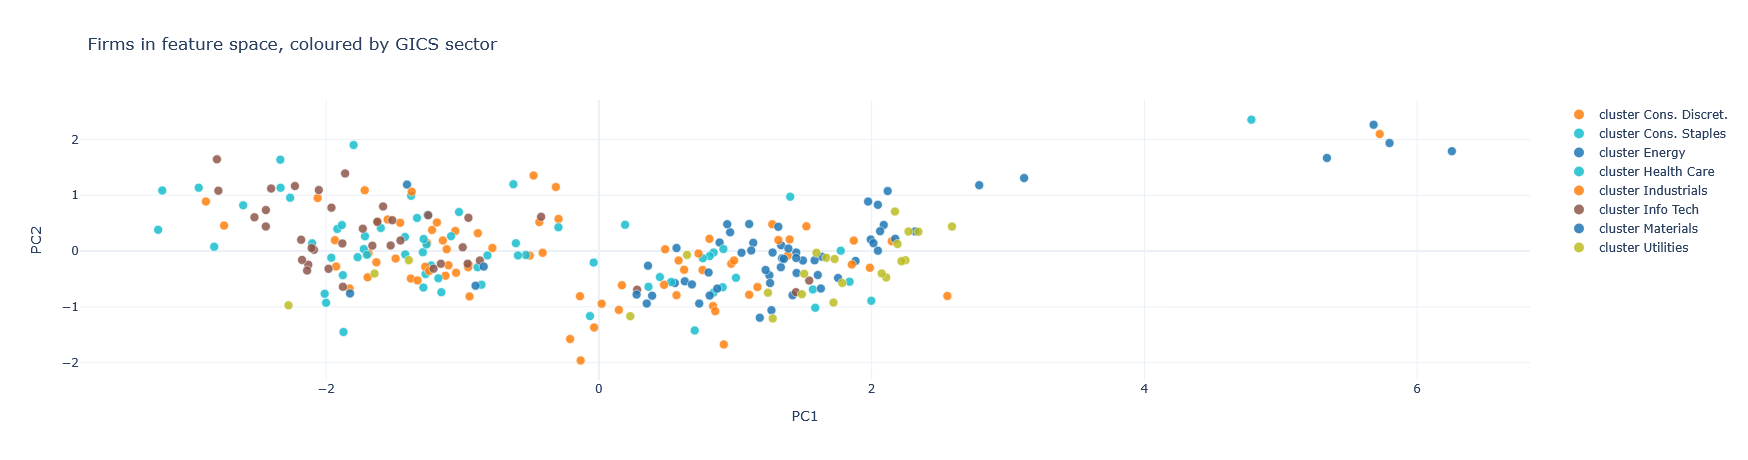

In [5]:
pcs = PCA(n_components=2, random_state=0).fit(X)
proj = pd.DataFrame(pcs.transform(X), index=panel.index, columns=["PC1", "PC2"])
proj = proj.join(panel[["sector", "region", "log_size"]])

print(f"variance explained: PC1 {pcs.explained_variance_ratio_[0]:.1%}, "
      f"PC2 {pcs.explained_variance_ratio_[1]:.1%}")

ec.scatter_clusters(proj, "PC1", "PC2", panel["sector"],
                    title="Firms in feature space, coloured by GICS sector",
                    hover=["sector", "region"])

Look at that plot before going on. The sectors do **not** occupy separate
regions of the space. Materials firms are scattered across it, and Consumer
Discretionary overlaps almost everything.

That is not an artefact of the simulation. It is the actual problem: a GICS
code tells you what a firm *sells*, and emissions intensity is driven by what
a firm *does* — its production technology. Two firms in the same sub-industry
can differ by an order of magnitude in energy intensity.

---
## 3. Interactive: the $k$-means playground

Move the slider and watch the partition change. Three things to notice:

1. The boundaries move a lot for small changes in $k$. There is no "true"
   partition being discovered here; you are imposing one.
2. Turning scaling off changes everything.
3. $k$-means always returns exactly $k$ non-empty clusters, whether or not the
   data contains any. It cannot tell you "there are no groups here".

In [6]:
def kmeans_plot(k=5, standardise=True, seed=0):
    data = X if standardise else raw
    km = KMeans(n_clusters=k, n_init=10, random_state=seed).fit(data)
    sil = silhouette_score(data, km.labels_)
    fig = ec.scatter_clusters(
        proj, "PC1", "PC2", km.labels_,
        title=(f"k-means, k={k}, "
               f"{'standardised' if standardise else 'RAW UNITS'} · "
               f"silhouette={sil:.3f} · inertia={km.inertia_:,.0f}"),
        hover=["sector", "region"])
    fig.show()


if HAS_WIDGETS:
    widgets.interact(
        kmeans_plot,
        k=widgets.IntSlider(min=2, max=12, step=1, value=5,
                            description="k", continuous_update=False),
        standardise=widgets.Checkbox(value=True, description="standardise"),
        seed=widgets.IntSlider(min=0, max=9, step=1, value=0,
                               description="seed", continuous_update=False))
else:
    # FALLBACK: edit these three values and re-run the cell.
    kmeans_plot(k=5, standardise=True, seed=0)

interactive(children=(IntSlider(value=5, continuous_update=False, description='k', max=12, min=2), Checkbox(va…

> **Core exercise 3.1** — Set `standardise=False` and sweep $k$ from 2 to 12.
> Which single feature is the algorithm effectively clustering on? Confirm your
> answer by checking the standard deviations printed in Section 2.
>
> **Core exercise 3.2** — With `standardise=True` and $k=5$, change the seed.
> How stable are the clusters? What does instability under reseeding tell you
> about whether you should be using this partition to fill missing data?

---
## 4. Choosing $k$

Three standard approaches, and one better one.

<details>
<summary><b>Maths: Inertia, silhouette and BIC</b> (click to expand)</summary>

**Inertia** (within-cluster sum of squares) for a partition
$C_1,\dots,C_k$ with centroids $\mu_1,\dots,\mu_k$:

$$W(k) = \sum_{m=1}^{k} \sum_{i \in C_m} \lVert x_i - \mu_m \rVert^2 .$$

$W(k)$ is non-increasing in $k$ and reaches zero at $k=n$, so it can never
select $k$ on its own. The "elbow" heuristic looks for the point where the
marginal reduction flattens, which is a judgement call, not a criterion.

**Silhouette** of point $i$:

$$s_i = \frac{b_i - a_i}{\max(a_i, b_i)}, \qquad s_i \in [-1, 1],$$

where $a_i$ is the mean distance from $i$ to the other points of its own
cluster and $b_i$ is the lowest mean distance from $i$ to the points of any
other cluster. Values near 1 are well separated, near 0 sit on a boundary,
and negative values are probably misassigned.

**BIC**, available for `GaussianMixture` because it has a likelihood:

$$\mathrm{BIC} = -2\log \hat{L} + p \log n,$$

with $p$ the number of free parameters. Lower is better. This is the only one
of the three that penalises complexity in a principled way.

</details>

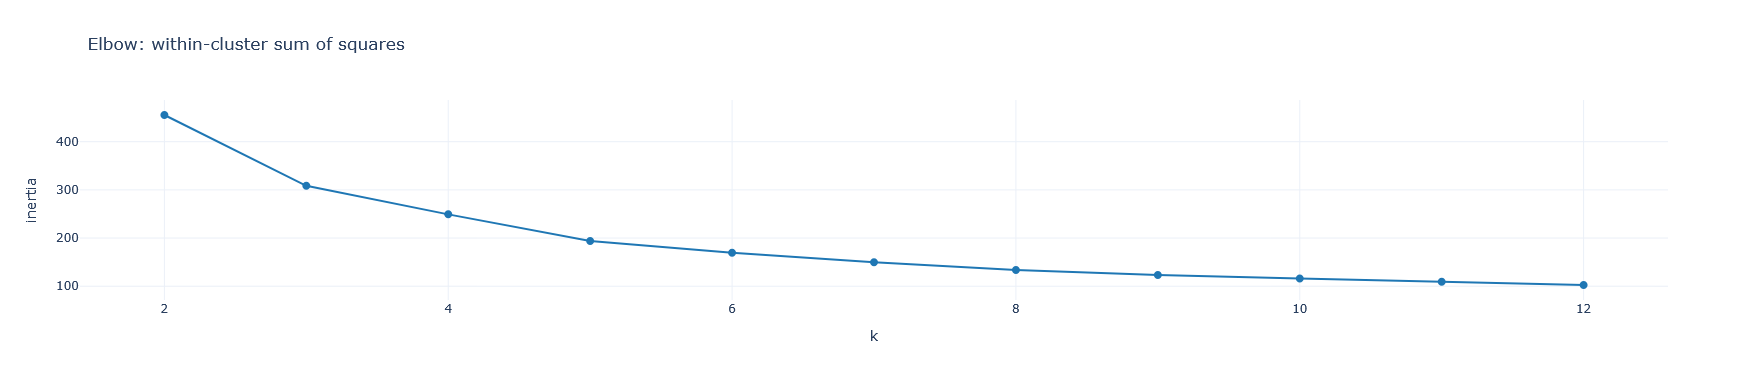

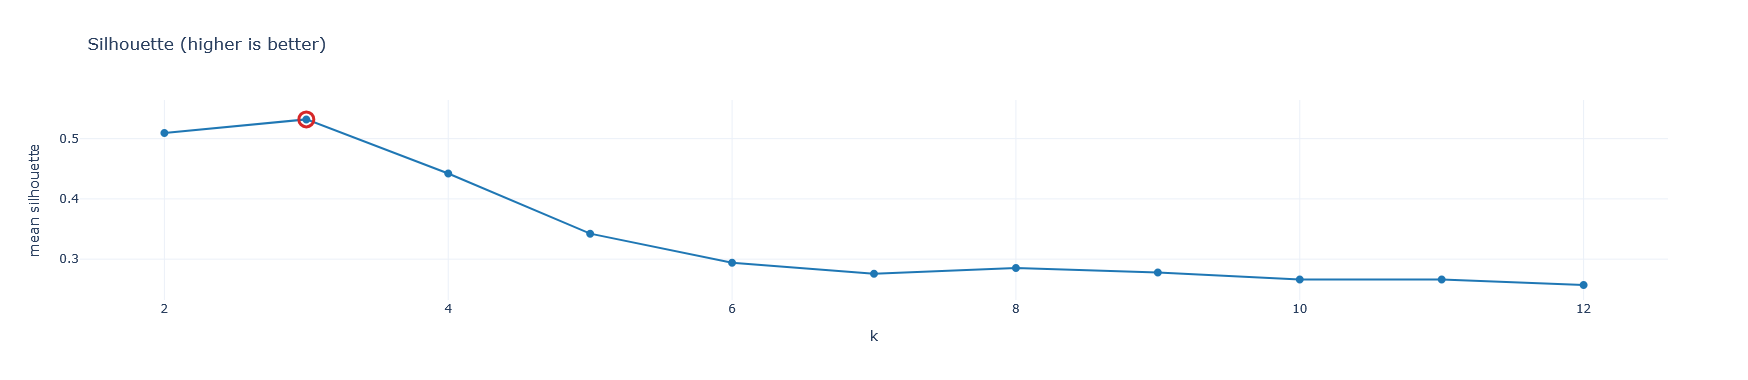

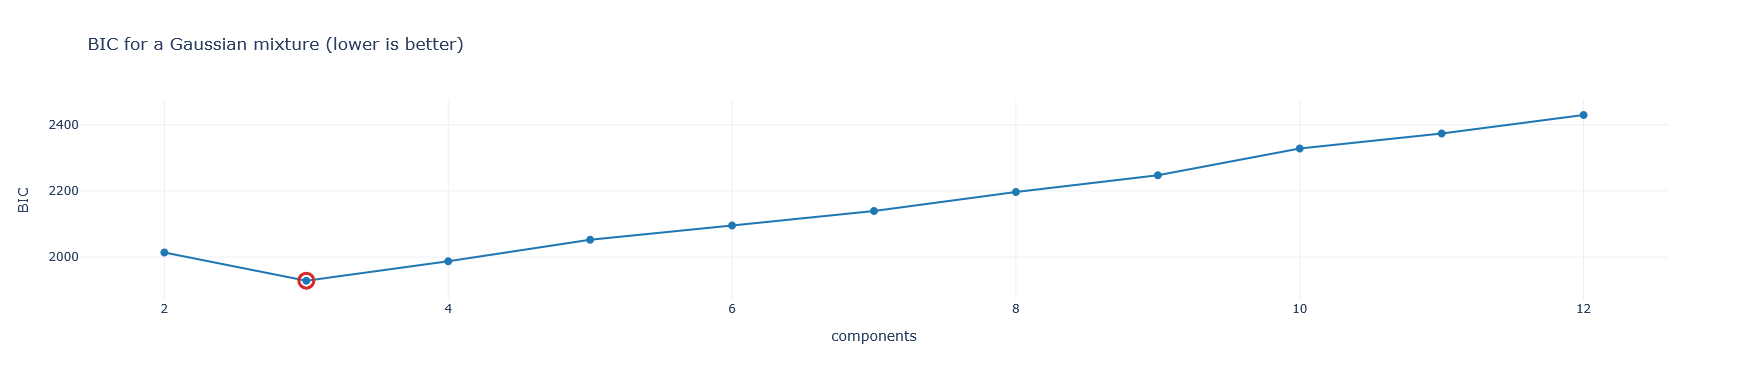

In [7]:
ks = range(2, 13)
inertia, sil, bic = [], [], []

for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(X)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(X, km.labels_))
    gm = GaussianMixture(n_components=k, covariance_type="full",
                         random_state=0).fit(X)
    bic.append(gm.bic(X))

ec.line_curve(ks, inertia, "Elbow: within-cluster sum of squares",
              "k", "inertia").show()
ec.line_curve(ks, sil, "Silhouette (higher is better)",
              "k", "mean silhouette", mark_best="max").show()
ec.line_curve(ks, bic, "BIC for a Gaussian mixture (lower is better)",
              "components", "BIC", mark_best="min").show()

The three criteria will not agree, and that is normal. Each measures a
different notion of a "good" partition, and none of them knows what you want
the clusters **for**.

The per-point silhouette distribution is far more informative than its mean.
A cluster whose points are mostly near zero is not a cluster; it is a slice
through a continuum that the algorithm cut because you asked it to.

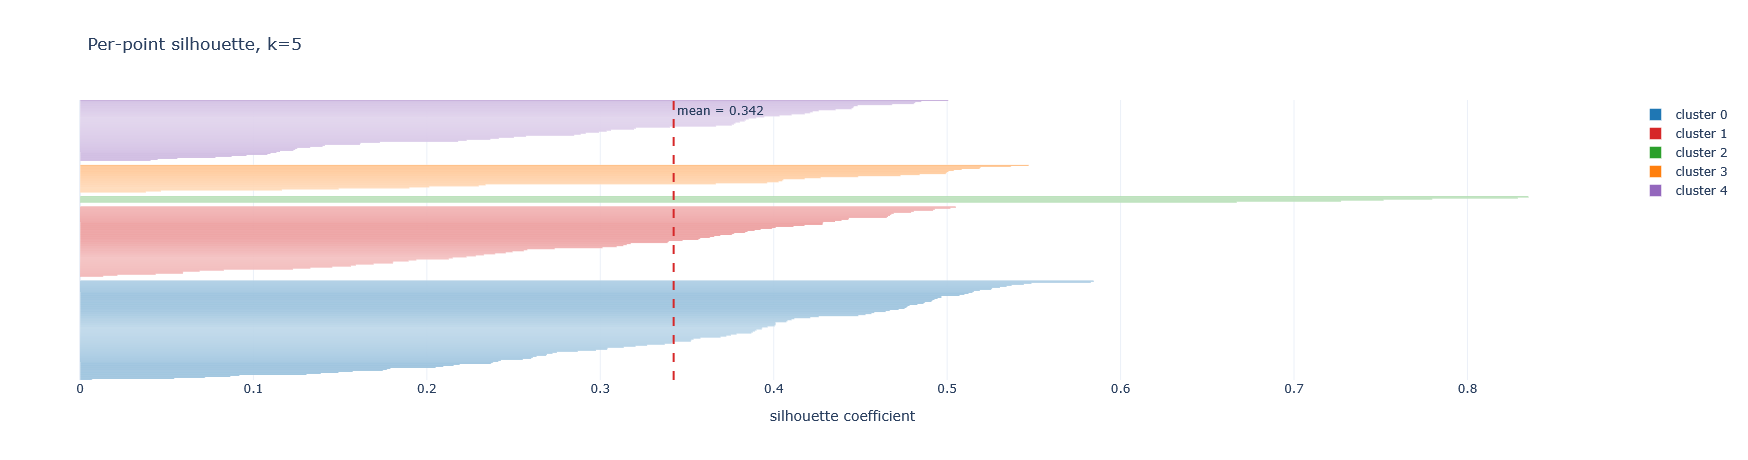

In [8]:
km5 = KMeans(n_clusters=5, n_init=10, random_state=0).fit(X)
ec.silhouette_figure(X, km5.labels_,
                     title="Per-point silhouette, k=5")

### The criterion that actually applies here

We are not clustering for its own sake. We are clustering **in order to fill
missing values**. So choose $k$ by the thing you care about: the masked-cell
imputation error.

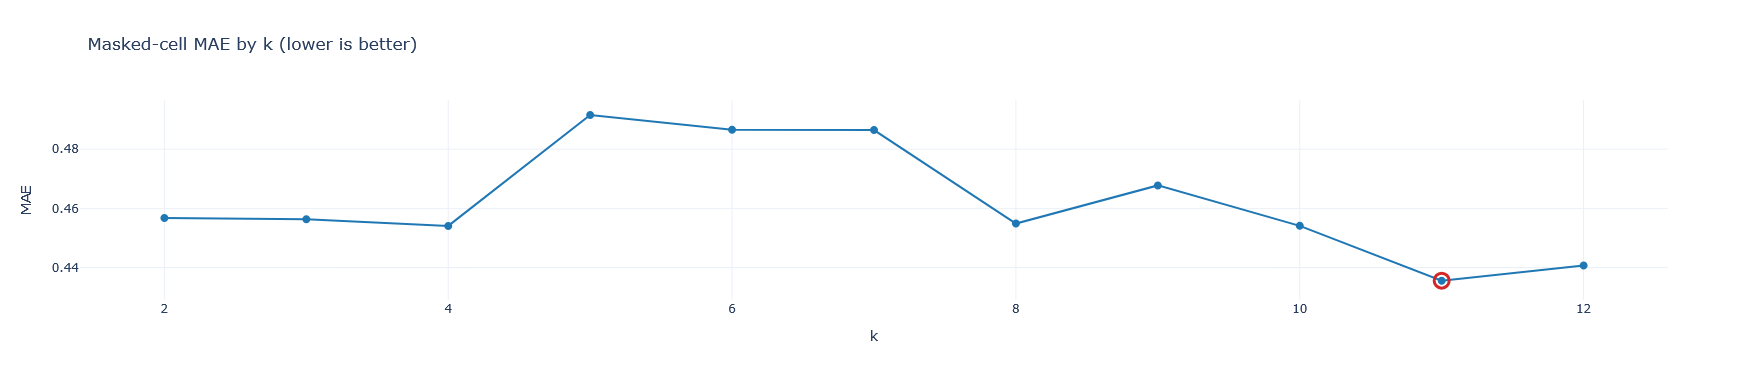

silhouette prefers k = 3
imputation error prefers k = 11


,silhouette,masked MAE,spearman
k,,,
2,0.509,0.457,0.963
3,0.532,0.456,0.963
4,0.442,0.454,0.961
5,0.342,0.492,0.958
6,0.294,0.487,0.955
7,0.276,0.486,0.955
8,0.285,0.455,0.958
9,0.278,0.468,0.957
10,0.266,0.454,0.960


In [9]:
rows = []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(X)
    groups = pd.Series(km.labels_, index=panel.index)
    filled = ec.impute_by_group(observed, groups)
    r = ec.masked_cell_benchmark(truth, observed, filled, mask)
    rows.append({"k": k, "silhouette": silhouette_score(X, km.labels_),
                 "masked MAE": r["MAE"], "spearman": r["spearman"]})

sweep = pd.DataFrame(rows).set_index("k")
ec.line_curve(sweep.index, sweep["masked MAE"],
              "Masked-cell MAE by k (lower is better)",
              "k", "MAE", mark_best="min").show()

print(f"silhouette prefers k = {sweep['silhouette'].idxmax()}")
print(f"imputation error prefers k = {sweep['masked MAE'].idxmin()}")
sweep.round(3)

**Two honest observations about that sweep.**

First, the two criteria disagree. Silhouette rewards geometrically tidy
partitions; imputation error rewards partitions that group firms with similar
emissions intensity. Those are different objectives and there is no reason
they should coincide.

Second — and this matters more — **the MAE curve is nearly flat**. Almost all
of the benefit comes from clustering *at all* rather than from the particular
$k$ you land on. Compare any value on that curve with the sector-median
benchmark from Section 1. Do not spend an afternoon tuning $k$ to the third
decimal; spend it on the feature set instead.

> **Core exercise 4.1** — Re-run the sweep for `water_intensity` instead of
> `emissions_intensity`. Does the same $k$ win?
>
> **Stretch exercise 4.2** — Now try `board_independence`. The improvement over
> the sector median will be close to nothing. Explain why, using the fact that
> the features you clustered on are all *operating* characteristics.

---
## 5. Soft assignment: firms that belong to more than one peer group

$k$-means forces every firm into exactly one cluster. A diversified
conglomerate genuinely is 60% one thing and 40% another, and pretending
otherwise throws away information you have.

A Gaussian mixture gives you `predict_proba`: a membership weight for each
cluster. You can then impute as a **weighted blend of several peer-group
medians** instead of picking one.

<details>
<summary><b>Maths: Gaussian mixture and responsibilities</b> (click to expand)</summary>

The model is

$$p(x) = \sum_{m=1}^{k} \pi_m \, \mathcal{N}(x \mid \mu_m, \Sigma_m),
\qquad \sum_m \pi_m = 1 .$$

Fitted by EM. The *responsibility* of component $m$ for point $i$ is the
posterior

$$\gamma_{im} = \frac{\pi_m \,\mathcal{N}(x_i \mid \mu_m, \Sigma_m)}
{\sum_{l} \pi_l \,\mathcal{N}(x_i \mid \mu_l, \Sigma_l)},$$

which is what `predict_proba` returns. A blended imputation then uses

$$\hat{x}_{i} = \sum_{m=1}^{k} \gamma_{im}\, \tilde{x}_m,$$

with $\tilde{x}_m$ the observed median of component $m$. Note that $k$-means
is the limiting case where every $\gamma_{im} \in \{0, 1\}$.

</details>

In [10]:
gm = GaussianMixture(n_components=5, covariance_type="full",
                     random_state=0).fit(X)
resp = pd.DataFrame(gm.predict_proba(X), index=panel.index,
                    columns=[f"c{m}" for m in range(5)])

# How confidently is each firm assigned?
confidence = resp.max(axis=1)
print(f"firms assigned with >90% confidence: {(confidence > 0.90).mean():.0%}")
print(f"firms genuinely split (max weight < 60%): {(confidence < 0.60).mean():.0%}")

print("\nFive least confidently assigned firms:")
amb = confidence.nsmallest(5).index
resp.loc[amb].join(panel.loc[amb, ["sector", "archetype"]]).round(3)

firms assigned with >90% confidence: 78%
firms genuinely split (max weight < 60%): 6%

Five least confidently assigned firms:


,c0,c1,c2,c3,c4,sector,archetype
firm_id,,,,,,,
F215,0.092,0.0,0.0,0.447,0.462,Cons. Staples,Process industrial
F185,0.286,0.0,0.0,0.249,0.464,Industrials,Process industrial
F104,0.470,0.0,0.0,0.397,0.133,Materials,Heavy extractive
F092,0.423,0.0,0.0,0.490,0.087,Industrials,Process industrial
F058,0.492,0.0,0.0,0.492,0.016,Industrials,Heavy extractive


In [11]:
# Blended imputation: weight each component's observed median by responsibility
comp_median = np.array([
    observed[gm.predict(X) == m].median() for m in range(5)])
comp_median = np.where(np.isnan(comp_median), observed.median(), comp_median)

blended = pd.Series(resp.to_numpy() @ comp_median, index=panel.index)
filled_soft = observed.fillna(blended)
filled_hard = ec.impute_by_group(
    observed, pd.Series(gm.predict(X), index=panel.index))

pd.DataFrame({
    "hard assignment": ec.masked_cell_benchmark(truth, observed, filled_hard, mask),
    "soft (blended)": ec.masked_cell_benchmark(truth, observed, filled_soft, mask),
}).T[["MAE", "RMSE", "sd_ratio", "spearman"]].round(3)

,MAE,RMSE,sd_ratio,spearman
hard assignment,0.458,0.571,0.986,0.963
soft (blended),0.452,0.564,0.985,0.966


---
## 6. Hierarchy: peer groups nested like a taxonomy

Sector classifications are hierarchical — sector, industry group, industry,
sub-industry. Agglomerative clustering produces the same shape of object, and
lets you **cut the tree at whatever level of granularity your sample size
supports**. That is a genuinely useful property: with 260 firms you cannot
support 60 peer groups, and the dendrogram makes the trade-off visible.

Agglomerative clustering also accepts a **precomputed distance matrix**, which
is what makes it the right tool for entity resolution in Section 9.

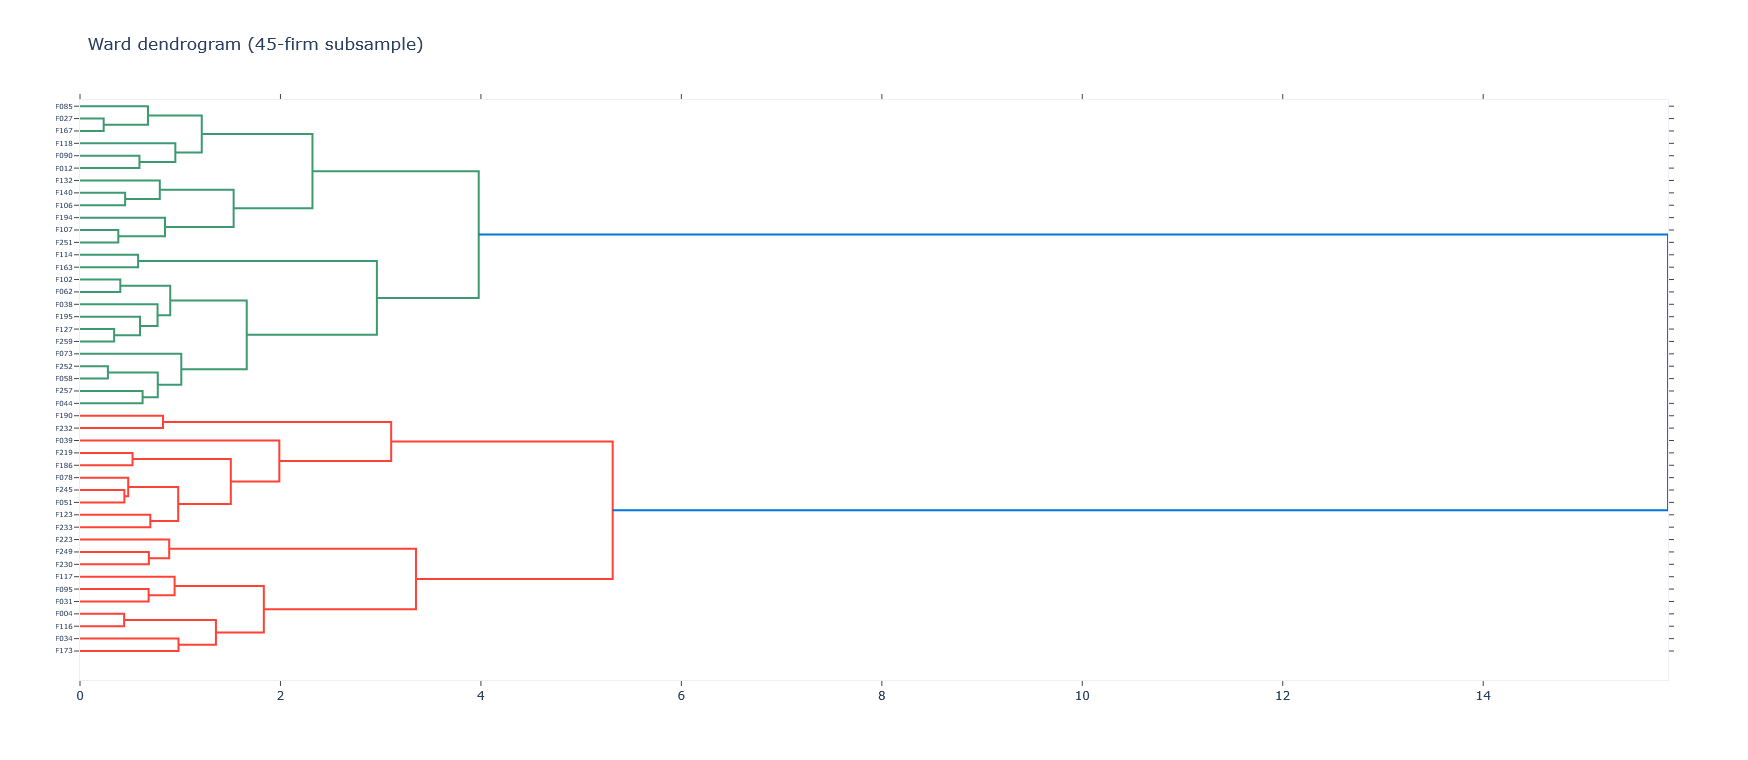

In [12]:
from plotly.figure_factory import create_dendrogram
from scipy.cluster.hierarchy import linkage

# Subsample so the leaves are legible
sub_idx = panel.sample(45, random_state=1).index
Xs = X[[panel.index.get_loc(i) for i in sub_idx]]

fig = create_dendrogram(Xs, orientation="left", labels=list(sub_idx),
                        linkagefun=lambda d: linkage(d, "ward"))
fig.update_layout(title="Ward dendrogram (45-firm subsample)",
                  height=760, template="plotly_white",
                  yaxis=dict(tickfont=dict(size=7)))
fig.show()

In [13]:
# Cutting the tree at different heights gives nested peer groups
for t in [4, 7, 10, 14]:
    lab = AgglomerativeClustering(n_clusters=None, distance_threshold=t,
                                  linkage="ward").fit_predict(X)
    groups = pd.Series(lab, index=panel.index)
    r = ec.masked_cell_benchmark(
        truth, observed, ec.impute_by_group(observed, groups), mask)
    print(f"cut at {t:>2}  ->  {len(set(lab)):>2} groups   "
          f"MAE={r['MAE']:.3f}   spearman={r['spearman']:.3f}")

cut at  4  ->  10 groups   MAE=0.500   spearman=0.956
cut at  7  ->   5 groups   MAE=0.480   spearman=0.958
cut at 10  ->   4 groups   MAE=0.459   spearman=0.960
cut at 14  ->   3 groups   MAE=0.456   spearman=0.963


---
## 7. Density: the firms that have no peers

Everything so far assigns *every* firm to a peer group, because that is what
partitioning methods do. But some firms genuinely have no peers — unusual
technology, unusual scale, a business nobody else is in.

For those firms the honest answer is **refuse to impute**. Density-based
methods are the only ones in the toolbox that can say so: they label a point
`-1`, meaning noise.

Our panel contains a handful of deliberately unique firms. Let us see whether
`DBSCAN` and `HDBSCAN` find them.

<details>
<summary><b>Maths: DBSCAN and the meaning of noise</b> (click to expand)</summary>

`DBSCAN` takes a radius $\varepsilon$ and a count `min_samples` $= p$. A point
is a **core point** if at least $p$ points lie within $\varepsilon$ of it.
Clusters are maximal sets of density-connected core points, together with the
border points within $\varepsilon$ of a core point. Everything else is
**noise**.

The number of clusters is an *output*, not an input. That is the property we
want: with $k$-means you must assert in advance how many peer groups exist.

`HDBSCAN` removes the $\varepsilon$ choice by building clusters across all
density thresholds and extracting the most persistent ones, which lets it find
clusters of differing density in the same dataset.

</details>

In [14]:
def density_plot(eps=0.60, min_samples=6, use_hdbscan=False):
    if use_hdbscan:
        lab = HDBSCAN(min_cluster_size=max(3, min_samples),
                      copy=True).fit_predict(X)
        label = f"HDBSCAN, min_cluster_size={max(3, min_samples)}"
    else:
        lab = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X)
        label = f"DBSCAN, eps={eps:.2f}, min_samples={min_samples}"

    n_clusters = len(set(lab) - {-1})
    n_noise = int((lab == -1).sum())
    # Of the firms flagged as noise, how many are the true orphans?
    caught = int(panel.loc[lab == -1, "is_orphan"].sum())
    total_orphans = int(panel["is_orphan"].sum())

    fig = ec.scatter_clusters(
        proj, "PC1", "PC2", lab,
        title=(f"{label}<br>{n_clusters} clusters · {n_noise} noise · "
               f"caught {caught}/{total_orphans} true orphans"),
        hover=["sector", "region"])
    fig.show()


if HAS_WIDGETS:
    widgets.interact(
        density_plot,
        eps=widgets.FloatSlider(min=0.20, max=1.60, step=0.05, value=0.60,
                                description="eps", continuous_update=False),
        min_samples=widgets.IntSlider(min=3, max=20, step=1, value=6,
                                      description="min_samples",
                                      continuous_update=False),
        use_hdbscan=widgets.Checkbox(value=False, description="use HDBSCAN"))
else:
    # FALLBACK: edit and re-run.
    density_plot(eps=0.60, min_samples=6, use_hdbscan=False)

interactive(children=(FloatSlider(value=0.6, continuous_update=False, description='eps', max=1.6, min=0.2, ste…

> **Core exercise 7.1** — Find settings that catch all of the true orphans.
> How many ordinary firms get flagged as noise at the same time? That
> trade-off is a policy decision, not a technical one: what is the cost of
> refusing to score a firm that could have been scored, versus the cost of
> scoring a firm you had no basis to score?
>
> **Stretch exercise 7.2** — Write an imputation function that fills within
> the density clusters and returns `NaN` for noise points. Report the coverage
> rate alongside the error, and argue for a defensible operating point.

---
## 8. Spatial clustering: from coordinates to industrial complexes

An asset register lists thousands of individual emissions sources. Many of
them belong to a single industrial complex. Grouping them is a clustering
problem with two features that rule out $k$-means immediately:

* you do not know how many complexes there are;
* isolated assets must **stay** isolated.

There is also a subtlety that catches almost everyone: **Euclidean distance on
raw latitude and longitude is wrong.** One degree of longitude is about 111 km
at the equator and about 87 km at Sydney's latitude. Use the haversine metric
on radians.

<details>
<summary><b>Maths: The haversine distance</b> (click to expand)</summary>

For two points $(\phi_1, \lambda_1)$ and $(\phi_2, \lambda_2)$ in radians,
with $\Delta\phi = \phi_2 - \phi_1$ and $\Delta\lambda = \lambda_2-\lambda_1$:

$$a = \sin^2\!\left(\tfrac{\Delta\phi}{2}\right)
    + \cos\phi_1 \cos\phi_2 \sin^2\!\left(\tfrac{\Delta\lambda}{2}\right),
\qquad d = 2R \arcsin\!\left(\sqrt{a}\right),$$

with $R \approx 6371$ km. `scikit-learn`'s `metric="haversine"` returns the
distance on the **unit sphere**, so an $\varepsilon$ expressed in kilometres
must be divided by $R$:

$$\varepsilon_{\text{rad}} = \varepsilon_{\text{km}} / 6371 .$$

</details>

In [15]:
facilities = ec.make_facilities(seed=3)
coords_rad = np.radians(facilities[["lat", "lon"]].to_numpy())

print(f"{len(facilities)} assets, "
      f"{(facilities['true_complex'] == '(none)').sum()} genuinely isolated")
facilities.head()

84 assets, 26 genuinely isolated


,lat,lon,emissions_ktco2e,true_complex
asset_id,,,,
A000,-21.7428,118.1568,180.0033,Pilbara
A001,-23.6734,118.4359,519.0325,Pilbara
A002,-22.4244,118.8024,104.2205,Pilbara
A003,-22.8385,118.4998,172.7832,Pilbara
A004,-22.7901,119.0023,468.7915,Pilbara


In [16]:
def complex_map(eps_km=80, min_samples=4, use_hdbscan=False):
    if use_hdbscan:
        lab = HDBSCAN(min_cluster_size=max(3, min_samples),
                      metric="haversine", copy=True).fit_predict(coords_rad)
        label = f"HDBSCAN (haversine), min_cluster_size={max(3, min_samples)}"
    else:
        lab = DBSCAN(eps=eps_km / 6371.0, min_samples=min_samples,
                     metric="haversine").fit_predict(coords_rad)
        label = f"DBSCAN (haversine), eps={eps_km} km, min_samples={min_samples}"

    ari = adjusted_rand_score(facilities["true_complex"], lab)
    fig = ec.facility_map(
        facilities, lab,
        title=(f"{label}<br>{len(set(lab) - {-1})} complexes · "
               f"{int((lab == -1).sum())} isolated · ARI vs truth = {ari:.3f}"))
    fig.show()


if HAS_WIDGETS:
    widgets.interact(
        complex_map,
        eps_km=widgets.IntSlider(min=10, max=200, step=10, value=80,
                                 description="eps (km)",
                                 continuous_update=False),
        min_samples=widgets.IntSlider(min=2, max=12, step=1, value=4,
                                      description="min_samples",
                                      continuous_update=False),
        use_hdbscan=widgets.Checkbox(value=False, description="use HDBSCAN"))
else:
    # FALLBACK: edit and re-run.
    complex_map(eps_km=80, min_samples=4, use_hdbscan=False)

interactive(children=(IntSlider(value=80, continuous_update=False, description='eps (km)', max=200, min=10, st…

In [17]:
# Once assets are grouped, aggregate emissions to the complex level.
labels = DBSCAN(eps=80 / 6371.0, min_samples=4,
                metric="haversine").fit_predict(coords_rad)
facilities["complex_id"] = labels

rollup = (facilities[facilities["complex_id"] != -1]
          .groupby("complex_id")
          .agg(n_assets=("emissions_ktco2e", "size"),
               total_ktco2e=("emissions_ktco2e", "sum"),
               centroid_lat=("lat", "mean"),
               centroid_lon=("lon", "mean"))
          .round(2))

unassigned = facilities.loc[facilities["complex_id"] == -1, "emissions_ktco2e"]
print(f"{len(unassigned)} isolated assets carrying "
      f"{unassigned.sum() / facilities['emissions_ktco2e'].sum():.1%} "
      f"of total emissions")
print("These do not disappear -- they are reported as individual sources.\n")
rollup

28 isolated assets carrying 13.9% of total emissions
These do not disappear -- they are reported as individual sources.



,n_assets,total_ktco2e,centroid_lat,centroid_lon
complex_id,,,,
0,12,3111.29,-22.86,118.77
1,11,2977.81,-32.52,151.08
2,12,5250.16,-22.26,148.14
3,8,3548.74,-23.87,151.25
4,7,1464.23,-38.22,146.46
5,6,2190.71,-32.27,115.80


> **Core exercise 8.1** — Sweep `eps_km` from 10 to 200 and record the ARI.
> Where does it peak, and what happens either side? Relate the two failure
> modes to the two ways a spatial join can go wrong.
>
> **Stretch exercise 8.2** — `HDBSCAN` needs no `eps`, but scores worse here
> on ARI. Look at the map and work out what it is doing differently. Which
> behaviour would you rather have when the downstream use is *attributing
> emissions to a corporate owner*?

---
## 9. Entity resolution: clustering to decide what counts as one firm

The same company arrives from four sources under four different strings. Before
you can join anything, you have to decide which strings refer to the same
entity. That is a clustering problem where the "features" are text.

The standard pipeline is **normalise → block → score → cluster → adjudicate**.
We will do the first four and leave you the fifth.

In [18]:
names = ec.make_name_variants(seed=5)
print(f"{len(names)} raw strings, {names['true_entity'].nunique()} true entities")
names.head(10)

45 raw strings, 12 true entities


,raw_name,true_entity
0,Incitec Pivt Ltd,Incitec Pivot
1,ORICA,Orica
2,Wesfarmers Ltd.,Wesfarmers
3,BHP Group Ltd.,BHP Group
4,AGL Energy Limitd,AGL Energy
5,Wesfarmers,Wesfarmers
6,RO TINTO Ltd,Rio Tinto
7,BHP GROUP Group Ltd,BHP Group
8,WOOLWORTHS.GROUP Limited,Woolworths Group
9,Wesfarmers Ltd,Wesfarmers


In [19]:
# Step 1: normalise. Case-fold, strip punctuation, drop legal-form tokens.
names["normalised"] = names["raw_name"].map(ec.normalised_name)
names[["raw_name", "normalised"]].head(10)

,raw_name,normalised
0,Incitec Pivt Ltd,incitec pivt
1,ORICA,orica
2,Wesfarmers Ltd.,wesfarmers
3,BHP Group Ltd.,bhp
4,AGL Energy Limitd,agl energy limitd
5,Wesfarmers,wesfarmers
6,RO TINTO Ltd,ro tinto
7,BHP GROUP Group Ltd,bhp
8,WOOLWORTHS.GROUP Limited,woolworths
9,Wesfarmers Ltd,wesfarmers


In [20]:
# Step 3: score. Jaccard distance on character trigrams.
# (Step 2, blocking, is skipped here because 45 rows is small. On a real
#  register you must block first -- see the stretch exercise.)
def distance_matrix(strings):
    s = list(strings)
    n = len(s)
    D = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            D[i, j] = D[j, i] = ec.token_set_distance(s[i], s[j])
    return D


D_norm = distance_matrix(names["normalised"])
D_raw = distance_matrix(names["raw_name"].str.lower())

# Step 4: cluster, and sweep the cut threshold.
print("threshold   clusters   ARI(normalised)   ARI(raw)")
for t in [0.30, 0.40, 0.50, 0.60, 0.70]:
    fit = lambda D: AgglomerativeClustering(
        n_clusters=None, distance_threshold=t,
        metric="precomputed", linkage="average").fit_predict(D)
    ln, lr = fit(D_norm), fit(D_raw)
    print(f"   {t:.2f}       {len(set(ln)):>4}          "
          f"{adjusted_rand_score(names['true_entity'], ln):.3f}"
          f"          {adjusted_rand_score(names['true_entity'], lr):.3f}")

threshold   clusters   ARI(normalised)   ARI(raw)
   0.30         22          0.766          0.354
   0.40         16          0.913          0.564
   0.50         14          0.949          0.754
   0.60         13          0.967          0.913
   0.70         13          0.967          0.967


Two things to take from that table.

**Normalisation earns more than the algorithm does.** At any fixed threshold
the normalised column beats the raw one substantially. Most of the work in
record linkage is text hygiene, not machine learning.

**The threshold is a policy choice with asymmetric costs.** Too low and you
over-split, leaving one firm looking like four uncovered ones. Too high and you
merge distinct companies, silently averaging them together. A false merge is
usually the worse error, because it is invisible downstream.

In [21]:
# Inspect the clusters at a chosen threshold, and find the mistakes.
THRESHOLD = 0.55
names["cluster"] = AgglomerativeClustering(
    n_clusters=None, distance_threshold=THRESHOLD,
    metric="precomputed", linkage="average").fit_predict(D_norm)

impure = (names.groupby("cluster")["true_entity"].nunique()
          .loc[lambda s: s > 1].index)
split = (names.groupby("true_entity")["cluster"].nunique()
         .loc[lambda s: s > 1].index)

print(f"clusters containing more than one true entity (false merges): {len(impure)}")
print(f"entities split across clusters (false splits): {len(split)}\n")

if len(impure):
    print("--- false merges ---")
    print(names[names["cluster"].isin(impure)]
          .sort_values("cluster")[["raw_name", "normalised",
                                   "true_entity", "cluster"]].to_string(index=False))
if len(split):
    print("\n--- false splits ---")
    print(names[names["true_entity"].isin(split)]
          .sort_values("true_entity")[["raw_name", "normalised",
                                       "true_entity", "cluster"]].to_string(index=False))

clusters containing more than one true entity (false merges): 0
entities split across clusters (false splits): 1


--- false splits ---
              raw_name normalised true_entity  cluster
        BHP Group Ltd.        bhp   BHP Group       11
  BHP GROUP Group Ltd         bhp   BHP Group       11
    BHP Group Pty Ltd         bhp   BHP Group       11
         BHP.Group Ltd        bhp   BHP Group       11
      BP Group Limited         bp   BHP Group       10


> **Core exercise 9.1** — Change `THRESHOLD` until you get zero false merges.
> How many false splits are you left with? Which error would you rather ship,
> and why does the answer depend on what the dataset is used for?
>
> **Core exercise 9.2** — Look closely at the false split reported above. A
> single dropped character has turned one large miner into the name of a
> *different real company*, and after normalisation the two strings are three
> characters apart. The algorithm's refusal to merge them is defensible; the
> ground truth says it is wrong. No threshold fixes this case. What would?
>
> **Stretch exercise 9.3** — Implement **blocking**. Group candidates by their
> first normalised token before computing distances, so you never compare
> "Orica" with "Woolworths". Time both versions with `%%timeit` and explain
> why blocking is not optional on a register of 50,000 names.
>
> **Stretch exercise 9.4** — `ec.normalised_name` drops legal-form tokens such
> as "limited". Find the row where a typo defeated this and the token survived
> into the normalised string. Suggest a fix that does not create new false
> merges — and note that a fuzzy match on legal suffixes is exactly how you
> would create some.

---
## 10. The payoff: peer group choice versus imputation error

Now put it together. **One imputation method** — group median — held fixed
throughout. **Six different definitions of the peer group.** The only thing
that changes is who counts as a peer.

The last row uses the true production technology, which you have not been
allowed to see until now. It is the oracle: the best any group-median method
could possibly do.

In [22]:
km_lab = pd.Series(KMeans(n_clusters=5, n_init=10, random_state=0)
                   .fit_predict(X), index=panel.index)

peer_groups = {
    "everyone (global median)": pd.Series("all", index=panel.index),
    "GICS sector": panel["sector"],
    "sector x region": panel["sector"].str.cat(panel["region"], sep="|"),
    "k-means, k=5": km_lab,
    "k-means x region": km_lab.astype(str).str.cat(panel["region"], sep="|"),
    "TRUE technology (oracle)": panel["archetype"],
}

results = {}
for name, groups in peer_groups.items():
    filled = ec.impute_by_group(observed, groups)
    results[name] = ec.masked_cell_benchmark(truth, observed, filled, mask)

table = pd.DataFrame(results).T[["MAE", "RMSE", "sd_ratio", "spearman"]]
table.round(3)

,MAE,RMSE,sd_ratio,spearman
everyone (global median),2.871,3.147,0.848,0.782
GICS sector,1.474,1.941,0.948,0.887
sector x region,1.723,2.599,0.992,0.822
"k-means, k=5",0.492,0.615,0.979,0.958
k-means x region,0.450,0.565,0.990,0.963
TRUE technology (oracle),0.412,0.490,0.992,0.973


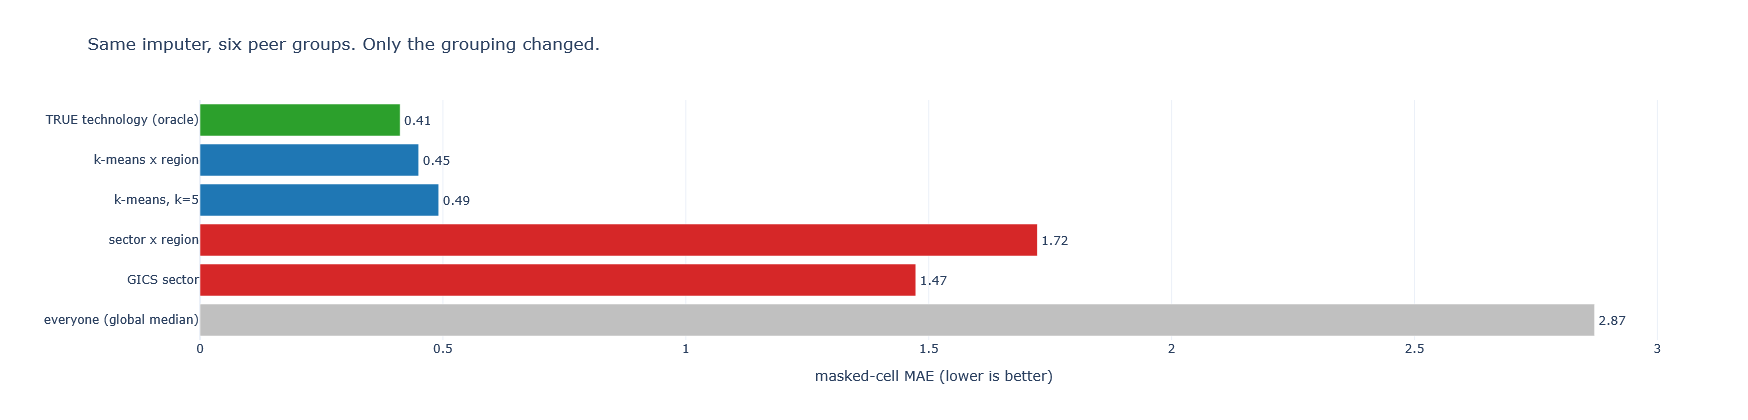

In [23]:
fig = go.Figure(go.Bar(
    x=table["MAE"], y=table.index, orientation="h",
    marker=dict(color=["#c0c0c0", "#d62728", "#d62728",
                       "#1f77b4", "#1f77b4", "#2ca02c"]),
    text=table["MAE"].round(2), textposition="outside"))
fig.update_layout(
    title="Same imputer, six peer groups. Only the grouping changed.",
    xaxis_title="masked-cell MAE (lower is better)",
    height=420, margin=dict(l=200))
fig.show()

**This is the single most important cell in the notebook.**

The method never changed. The features never changed. The missing cells never
changed. Only the definition of "who is this firm like" changed, and the error
moved by roughly a factor of three between the sector default and a clustered
peer group.

Note also that the clustered peer group recovers most, but not all, of the gap
to the oracle. The residual is what you lose by not observing production
technology directly — and it tells you what an asset-level dataset like Climate
TRACE would actually be worth to you.

---
## 11. When it all breaks: MNAR

Everything above assumed the gaps were **MAR** — missing at random conditional
on something you can see. Real ESG missingness usually is not. Firms withhold
figures *because* those figures are unflattering, which makes the probability
of a gap depend on the value in the gap.

Let us re-run the whole comparison with MNAR gaps and see what survives.

In [24]:
mask_mnar = ec.ampute(panel, COL, rate=0.30, mechanism="MNAR", seed=11)
observed_mnar = truth.mask(mask_mnar)

print("Mean of the HIDDEN values vs the values you get to KEEP:")
for label, m in [("MAR ", mask), ("MNAR", mask_mnar)]:
    print(f"  {label}: hidden={truth[m].mean():.2f}   "
          f"kept={truth[~m].mean():.2f}   "
          f"gap={truth[m].mean() - truth[~m].mean():+.2f}")
print("\nUnder MNAR the firms you cannot see are the high emitters.")
print("No imputer can recover that from the observed data alone.")

Mean of the HIDDEN values vs the values you get to KEEP:
  MAR : hidden=1.86   kept=3.82   gap=-1.96
  MNAR: hidden=5.98   kept=2.05   gap=+3.92

Under MNAR the firms you cannot see are the high emitters.
No imputer can recover that from the observed data alone.


In [25]:
results_mnar = {}
for name, groups in peer_groups.items():
    filled = ec.impute_by_group(observed_mnar, groups)
    results_mnar[name] = ec.masked_cell_benchmark(
        truth, observed_mnar, filled, mask_mnar)

comparison = pd.concat(
    {"MAR": pd.DataFrame(results).T[["MAE", "sd_ratio", "spearman"]],
     "MNAR": pd.DataFrame(results_mnar).T[["MAE", "sd_ratio", "spearman"]]},
    axis=1)
comparison.round(3)

MAR                     MNAR                  
                            MAE sd_ratio spearman    MAE sd_ratio spearman
everyone (global median)  2.871    0.848    0.782  4.821    0.631    0.644
GICS sector               1.474    0.948    0.887  2.254    0.741    0.864
sector x region           1.723    0.992    0.822  2.439    0.748    0.839
k-means, k=5              0.492    0.979    0.958  1.789    0.750    0.897
k-means x region          0.450    0.990    0.963  1.743    0.759    0.896
TRUE technology (oracle)  0.412    0.992    0.973  1.491    0.800    0.918

Look at the oracle row. **Even knowing the true peer group, MNAR error is
several times MAR error**, and `sd_ratio` collapses — the filled column is far
too narrow, because every fill is pulled towards the median of the firms that
chose to disclose.

That is the lecture's central claim, demonstrated rather than asserted: under
MNAR, better clustering does not save you. The gaps are informative, and
filling them destroys the information.

In [26]:
# So: keep the flag. One extra column, no assumptions, and it preserves
# exactly the signal that imputation erases.
augmented = pd.DataFrame({
    COL: ec.impute_by_group(observed_mnar, km_lab),
    f"{COL}_was_missing": mask_mnar.astype(int),
})

print("Mean TRUE emissions intensity, split by whether the firm disclosed:")
print(augmented.assign(true=truth)
      .groupby(f"{COL}_was_missing")["true"]
      .agg(["count", "mean"]).round(3).to_string())
print("\nThe indicator alone separates the groups. That is free information,")
print("and it is thrown away by every pipeline that fills silently.")

Mean TRUE emissions intensity, split by whether the firm disclosed:
                                 count   mean
emissions_intensity_was_missing              
0                                  182  2.053
1                                   78  5.977

The indicator alone separates the groups. That is free information,
and it is thrown away by every pipeline that fills silently.


---
## 12. The circularity trap

One last hazard. You need complete data to cluster, and you are clustering in
order to complete the data.

If you cluster on a feature set that includes the variable you are about to
impute, you have leaked the answer into the peer-group definition, and your
masked-cell benchmark will flatter you. Break the circle by clustering only on
variables that are **always observed**.

In [27]:
# The wrong way: impute first with a crude method, then cluster on everything
# including the imputed target, then impute again "properly".
crude = observed.fillna(observed.median())
X_leaky = StandardScaler().fit_transform(
    pd.concat([panel[FEATURES], crude.rename(COL)], axis=1))
leaky_lab = pd.Series(KMeans(n_clusters=5, n_init=10, random_state=0)
                      .fit_predict(X_leaky), index=panel.index)

clean = ec.masked_cell_benchmark(
    truth, observed, ec.impute_by_group(observed, km_lab), mask)
leaky = ec.masked_cell_benchmark(
    truth, observed, ec.impute_by_group(observed, leaky_lab), mask)

pd.DataFrame({"clean (features only)": clean,
              "leaky (target in feature set)": leaky}).T[
    ["MAE", "RMSE", "spearman"]].round(3)

,MAE,RMSE,spearman
clean (features only),0.492,0.615,0.958
leaky (target in feature set),0.555,0.686,0.952


> **Stretch exercise 12.1** — The leaky version may or may not look better on
> this run. Either way, explain why the comparison is not a fair test of the
> method, and describe what would have to change for it to become one.

---
## 13. Exercises

### Core

1. **Feature design.** Add `region` to the clustering features as a one-hot
   encoding (`sklearn.preprocessing.OneHotEncoder`) rather than crossing it
   afterwards. Does the imputation error improve? Should it?

2. **A different target.** Repeat Section 10 for `water_intensity`. Then repeat
   it for `board_independence` and explain, in two or three sentences, why the
   clustered peer group barely helps for the second one.

3. **Stability.** Re-run the Section 10 comparison for ten random seeds of
   `KMeans` and report the spread of the MAE. Would you be comfortable
   defending a single run to a client?

4. **Refusing to impute.** Using `HDBSCAN`, produce a filled column that
   returns `NaN` for noise points. Report both the error *and* the coverage
   rate. Argue for an operating point.

### Stretch

5. **Beyond group medians.** Replace `ec.impute_by_group` with
   `sklearn.impute.KNNImputer` and `IterativeImputer`
   (`from sklearn.experimental import enable_iterative_imputer` first). Does
   the peer group still matter as much once the imputer is smarter?

6. **Low-rank completion.** Implement the soft-impute loop from the lecture
   appendix using `TruncatedSVD` — fill, decompose, reconstruct, overwrite the
   observed entries, repeat. Compare against the clustered group median when
   *two* target columns are missing simultaneously.

7. **The exclusion list.** Fill the panel three defensible ways, form the
   bottom-decile exclusion list from each, and report the pairwise overlap.
   This reproduces the closing slide of the lecture. How much of the
   disagreement sits among firms with the most missing data?

8. **Bring your own data.** Swap the synthetic panel for the World Bank
   sovereign ESG indicators used in Lab 7a. Cluster countries *without* using
   income, then colour the clusters by World Bank income group. The agreement
   rate is the ingrained income bias, measured rather than asserted.

---

### What to take away

* The peer group does the work. The imputer is mostly a detail.
* Standardise before any distance-based method, and know that standardising is
  itself a modelling choice.
* Choose $k$ by the task you actually have, and do not over-tune it — most of
  the gain comes from clustering at all.
* Density methods can say "no peers". That is a feature. Some firms should not
  be imputed.
* Under MNAR, none of this saves you. Keep the missingness flag and report the
  fill rate.

### Where this goes next

Lab **7a** builds the geospatial layer this notebook's Section 8 previews;
lab **7b** takes the imputation ladder further with `IterativeImputer` and
matrix completion. Both use `esgclust.py`, so the helpers are already loaded.